# Data Preparation

This notebook prepares the climate data for analysis by:
1. Concatenating historical and future projection datasets
2. Computing Cloud Radiative Effects (CRE) for shortwave and longwave radiation
3. Saving processed datasets for analysis

In [1]:
import sys
sys.path.append('..')

from utils import (
    load_dataset,
    compute_cloud_radiative_effect,
    plot_spatial_map
)
import xarray as xr
import matplotlib.pyplot as plt

# Concatenate Historical and SSP Data

Merge historical (1850-2014) and SSP projection (2015-2100) datasets.

In [ ]:
# Load historical and SSP data for surface temperature
hist_tas = load_dataset("../../data/CanESM5_historical_tas.nc")
ssp_tas = load_dataset("../../data/CanESM5_ssp_tas.nc")

# Concatenate along time dimension
tas_1850_2100 = xr.concat([hist_tas["tas"], ssp_tas["tas"]], dim="time")
tas_1850_2100.to_netcdf("../../data/CanESM5_1850-2100_tas.nc")

print(f"Saved surface temperature (tas) 1850-2100: {tas_1850_2100.shape}")

✓ Saved surface temperature (tas) 1850-2100: (25, 3012, 64, 128)


In [2]:
# Load and concatenate rsut (TOA outgoing shortwave radiation)
hist_rsut = load_dataset("../../data/CanESM5_hist_rsut.nc")
ssp_rsut = load_dataset("../../data/CanESM5_ssp_rsut.nc")

rsut_1850_2100 = xr.concat([hist_rsut["rsut"], ssp_rsut["rsut"]], dim="time")
rsut_1850_2100.to_netcdf("../../data/CanESM5_1850-2100_rsut.nc")

print(f"Saved rsut 1850-2100: {rsut_1850_2100.shape}")

Saved rsut 1850-2100: (25, 3012, 64, 128)


In [5]:
# Load and concatenate rlut (TOA outgoing longwave radiation)
hist_rlut = load_dataset("../../data/CanESM5_hist_rlut.nc")
ssp_rlut = load_dataset("../../data/CanESM5_ssp_rlut.nc")

rlut_1850_2100 = xr.concat([hist_rlut["rlut"], ssp_rlut["rlut"]], dim="time")
rlut_1850_2100.to_netcdf("../../data/CanESM5_1850-2100_rlut.nc")

print(f"Saved rlut 1850-2100: {rlut_1850_2100.shape}")

Saved rlut 1850-2100: (25, 3012, 64, 128)


## Compute Cloud Radiative Effects

Cloud Radiative Effect (CRE):
- **Shortwave CRE** (SWCRE)
- **Longwave CRE** (LWCRE)

In [5]:
# Load all-sky and clear-sky shortwave data
rsut = load_dataset( "../../data/CanESM5_1850-2100_rsut.nc")
rsutcs = load_dataset("../../data/CanESM_1850-2100_rsutcs.nc")

rsut_da = rsut["rsut"]
rsutcs_da = rsutcs["rsutcs"]

# Compute Shortwave CRE
rsut_da, rsutcs_da = xr.align(rsut_da, rsutcs_da, join="inner")

ESM5_data = xr.merge([
    rsut_da.to_dataset(name="rsut"),
    rsutcs_da.to_dataset(name="rsutcs"),
])

swcre = ESM5_data["rsut"] - ESM5_data["rsutcs"]

swcre_ds = swcre.to_dataset(name="cre")
swcre_ds["cre"].attrs["long_name"] = "Shortwave Cloud Radiative Effect"
swcre_ds["cre"].attrs["description"] = "Computed as rsut - rsutcs"
# Save
swcre_ds.to_netcdf("../../data/CanESM5_1850-2100_rsutcre.nc")

print(f"Saved Shortwave CRE: {swcre_ds}")

Saved Shortwave CRE: <xarray.Dataset> Size: 2GB
Dimensions:  (time: 3012, lat: 64, lon: 128, member: 25)
Coordinates:
  * time     (time) object 24kB 1850-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * member   (member) int64 200B 0 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
Data variables:
    cre      (member, time, lat, lon) float32 2GB 11.61 11.45 11.21 ... 0.0 0.0


In [7]:
# Load all-sky and clear-sky longwave data
rlut = load_dataset( "../../data/CanESM5_1850-2100_rlut.nc")
rlutcs = load_dataset("../../data/CanESM5_1850-2100_rlutcs.nc")

rlut_da = rlut["rlut"]
rlutcs_da = rlutcs["rlutcs"]

# Compute Longwave CRE
rlut_da, rlutcs_da = xr.align(rlut_da, rlutcs_da, join="inner")

ESM5_data = xr.merge([
    rlut_da.to_dataset(name="rlut"),
    rlutcs_da.to_dataset(name="rlutcs"),
])

lwcre = ESM5_data["rlut"] - ESM5_data["rlutcs"]

lwcre_ds = lwcre.to_dataset(name="cre")
lwcre_ds["cre"].attrs["long_name"] = "Longwave Cloud Radiative Effect"
lwcre_ds["cre"].attrs["description"] = "Computed as rlut - rlutcs"
# Save
lwcre_ds.to_netcdf("../../data/CanESM5_1850-2100_rlutcre.nc")

print(f"Saved Longwave CRE: {lwcre_ds}")

Saved Longwave CRE: <xarray.Dataset> Size: 2GB
Dimensions:  (time: 3012, lat: 64, lon: 128, member: 25)
Coordinates:
  * time     (time) object 24kB 1850-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * member   (member) int64 200B 0 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
Data variables:
    cre      (member, time, lat, lon) float32 2GB -8.854 -8.657 ... -25.21


## Verify Data with Visualizations

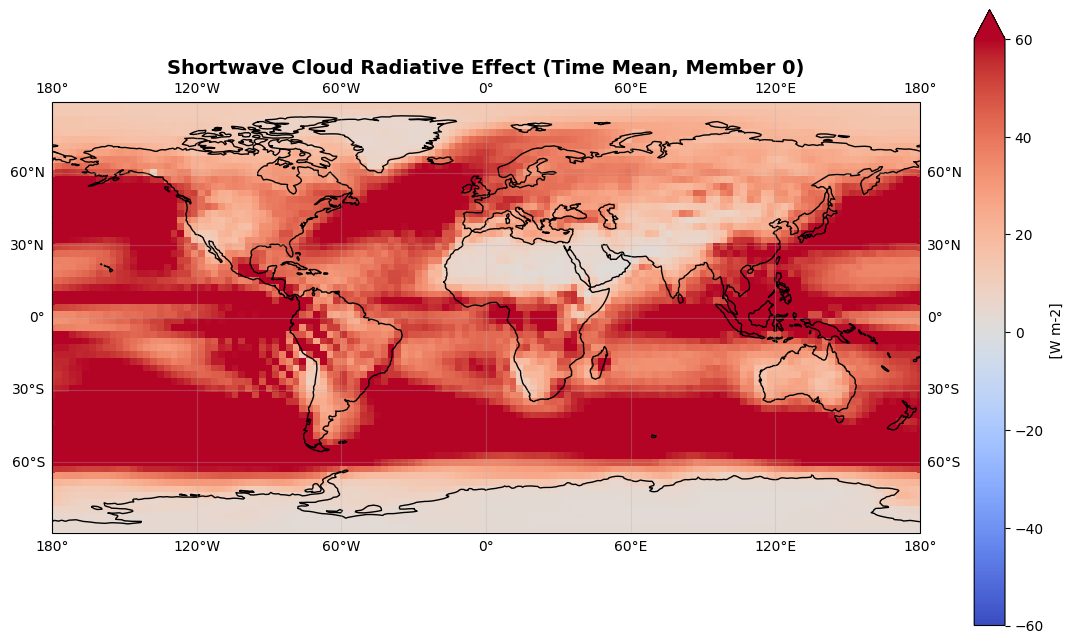

In [8]:
# Plot Shortwave CRE spatial pattern
plot_spatial_map(
    swcre,
    title="Shortwave Cloud Radiative Effect (Time Mean, Member 0)",
    vmin=-60,
    vmax=60
)
plt.show()

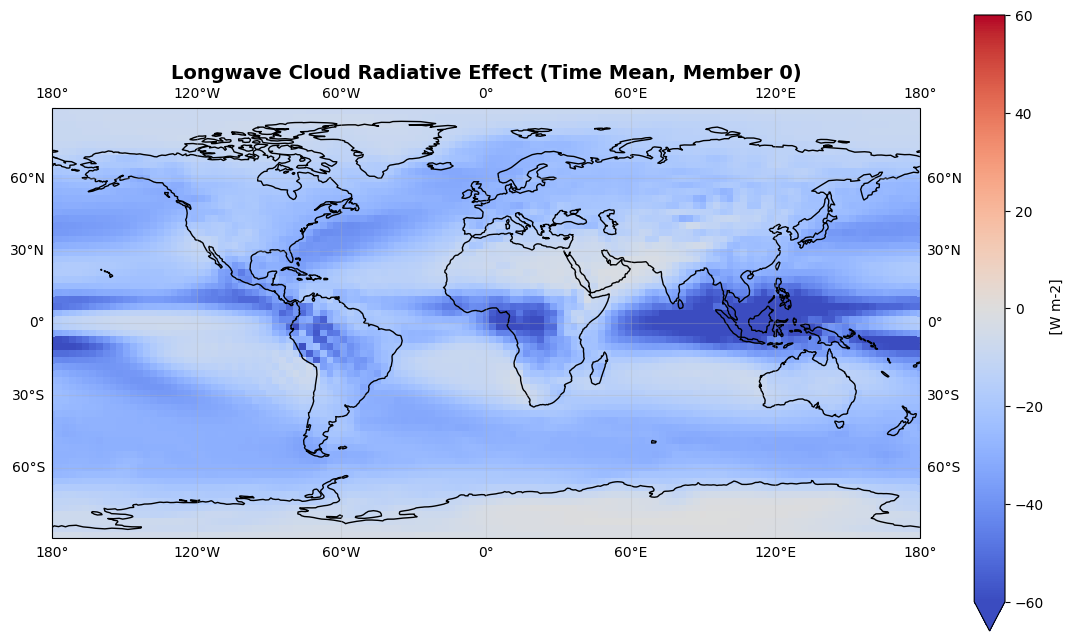

In [9]:
# Plot Longwave CRE spatial pattern
plot_spatial_map(
    lwcre,
    title="Longwave Cloud Radiative Effect (Time Mean, Member 0)",
    vmin=-60,
    vmax=60
)
plt.show()